# Constrained Spatial Split Design

Goal: choose `d` (max mean distance to k=3 nearest training wells) for the constrained 90/5/5 spatial split.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

ROOT = Path("../../..").resolve()
DATA_PATH = ROOT / "../data/merged.parquet"

In [2]:
# Load coordinates — one row per well
df = pq.read_table(DATA_PATH, columns=["id", "x_25833", "y_25833"]).to_pandas()
coords = df.drop_duplicates("id").dropna(subset=["x_25833", "y_25833"]).reset_index(drop=True)
print(f"Total wells: {len(coords)}")
coords.head()

Total wells: 1040


,id,x_25833,y_25833
0,LFU_25470023,409854.0,5919495.0
1,LFU_25470024,409856.0,5919494.0
2,LFU_25480025,422075.0,5923197.0
3,LFU_25480026,412183.0,5923933.0
4,LFU_25481088,421783.0,5925854.0


In [3]:
# Compute mean distance to k=3 nearest neighbours (excluding self)
K = 3
XY = coords[["x_25833", "y_25833"]].to_numpy()
tree = cKDTree(XY)

# k+1 because the nearest neighbour of a point is itself
dists, _ = tree.query(XY, k=K + 1)
dists_neighbours = dists[:, 1:]  # drop self
mean_dist_k3 = dists_neighbours.mean(axis=1)  # metres (EPSG:25833)

coords["mean_dist_k3"] = mean_dist_k3
print(f"Mean dist to 3 nearest neighbours (km):")
print(pd.Series(mean_dist_k3 / 1000).describe().round(2))

Mean dist to 3 nearest neighbours (km):
count    1040.00
mean        3.10
std         2.27
min         0.00
25%         1.54
50%         2.58
75%         4.15
max        20.59
dtype: float64


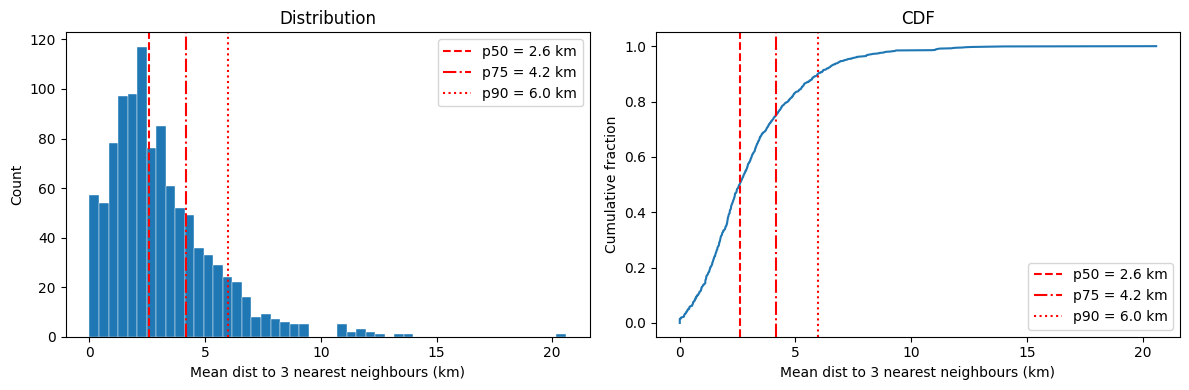

In [4]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

km = mean_dist_k3 / 1000

axes[0].hist(km, bins=50, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Mean dist to 3 nearest neighbours (km)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution")

for p, ls in [(50, "--"), (75, "-."), (90, ":")]:
    v = np.percentile(km, p)
    axes[0].axvline(v, color="red", linestyle=ls, label=f"p{p} = {v:.1f} km")
axes[0].legend()

axes[1].plot(np.sort(km), np.linspace(0, 1, len(km)))
axes[1].set_xlabel("Mean dist to 3 nearest neighbours (km)")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("CDF")
for p, ls in [(50, "--"), (75, "-."), (90, ":")]:
    v = np.percentile(km, p)
    axes[1].axvline(v, color="red", linestyle=ls, label=f"p{p} = {v:.1f} km")
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# For a candidate d, how many wells qualify as holdout?
# A well qualifies if its mean_dist_k3 <= d (i.e. it has 3 close neighbours).
# For 90/5/5: holdout = 5% of total wells.

n_total = len(coords)
n_holdout_target = int(round(n_total * 0.05))
print(f"Total wells: {n_total}")
print(f"Target holdout (5%): {n_holdout_target}")
print()

candidates = []
for p in [25, 50, 60, 75, 90]:
    d = np.percentile(mean_dist_k3, p)
    n_qualify = (mean_dist_k3 <= d).sum()
    candidates.append({"percentile": p, "d_km": d / 1000, "n_qualify": n_qualify, "target": n_holdout_target, "feasible": n_qualify >= n_holdout_target})

pd.DataFrame(candidates).round(2)

Total wells: 1040
Target holdout (5%): 52



,percentile,d_km,n_qualify,target,feasible
0,25,1.54,260,52,True
1,50,2.58,520,52,True
2,60,3.10,624,52,True
3,75,4.15,780,52,True
4,90,5.97,936,52,True


In [20]:
# Pick a d and simulate the constrained split
# Adjust D_KM based on the table above — start with p50
D_KM = np.percentile(mean_dist_k3, 90) / 1000
print(f"Using d = {D_KM:.2f} km")

eligible_holdout = coords[coords["mean_dist_k3"] <= D_KM * 1000]["id"].tolist()
print(f"Eligible holdout wells: {len(eligible_holdout)} / {n_total}")
print(f"Need for 5% holdout:    {n_holdout_target}")
print(f"Feasible: {len(eligible_holdout) >= n_holdout_target}")

Using d = 5.97 km
Eligible holdout wells: 936 / 1040
Need for 5% holdout:    52
Feasible: True


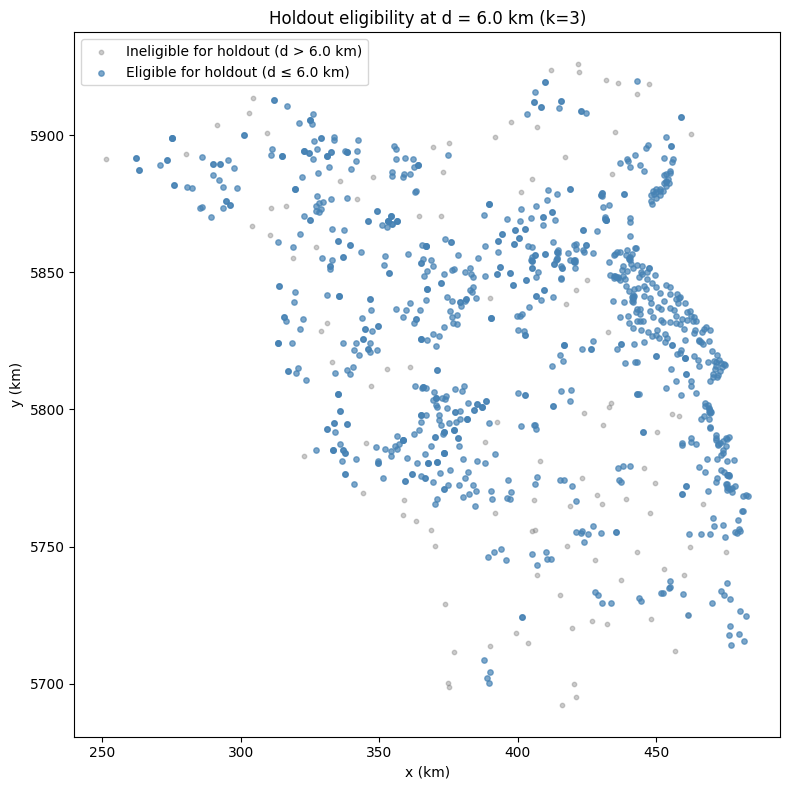

In [21]:
# Spatial map: eligible vs ineligible holdout candidates
fig, ax = plt.subplots(figsize=(8, 8))

elig = coords[coords["mean_dist_k3"] <= D_KM * 1000]
inelig = coords[coords["mean_dist_k3"] > D_KM * 1000]

ax.scatter(inelig["x_25833"] / 1000, inelig["y_25833"] / 1000,
           s=10, alpha=0.4, label=f"Ineligible for holdout (d > {D_KM:.1f} km)", color="gray")
ax.scatter(elig["x_25833"] / 1000, elig["y_25833"] / 1000,
           s=15, alpha=0.7, label=f"Eligible for holdout (d ≤ {D_KM:.1f} km)", color="steelblue")

ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title(f"Holdout eligibility at d = {D_KM:.1f} km (k=3)")
ax.legend()
plt.tight_layout()
plt.show()